# Projet Deep Learning – EMSI Casablanca 2025–2026
## Partie I : MLP et Ingénierie PyTorch
### Classification supervisée sur données tabulaires réelles

**Dataset choisi :** Breast Cancer Wisconsin  
**Objectif :** Maîtriser la construction d'un MLP avec PyTorch, l'initialisation, la gestion des paramètres, la sauvegarde et l'évaluation.

---
## 0. Imports et Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Imports OK')
print(f'PyTorch version : {torch.__version__}')

Imports OK
PyTorch version : 2.11.0+cpu


---
## 1. Concepts Fondamentaux de PyTorch

### 1.1 `nn.Module` : la classe de base

Tout modèle PyTorch hérite de `nn.Module`. Cette classe fournit :
- **`forward()`** : définit le passage avant (propagation avant)
- **`parameters()`** / **`named_parameters()`** : itère sur les paramètres apprenables
- **`state_dict()`** : sérialise l'état complet du modèle (poids + biais)
- **`load_state_dict()`** : restaure un état sauvegardé
- **`to(device)`** : déplace le modèle vers CPU ou GPU

### 1.2 Paramètres et Gradients

Un **paramètre** (`nn.Parameter`) est un tenseur avec `requires_grad=True`. Après l'appel à `.backward()`, PyTorch remplit automatiquement le champ `.grad` de chaque paramètre via la **rétropropagation** (backpropagation through the computation graph).

### 1.3 Propagation avant et rétropropagation

- **Forward pass** : calcul de la sortie à partir de l'entrée via les couches du réseau.
- **Backward pass** : calcul des gradients de la perte par rapport à chaque paramètre via la règle de chaîne (chain rule).

$$\frac{\partial \mathcal{L}}{\partial W} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial W}$$

### 1.4 `state_dict` et `device`

- **`state_dict`** : dictionnaire ordonné `{nom_couche: tenseur}` utilisé pour sauvegarder/charger un modèle.
- **`device`** : `'cpu'` ou `'cuda'`. Données et modèle doivent être sur le même device.

In [2]:
# Illustration : tenseur avec gradient
x = torch.tensor([2.0, 3.0], requires_grad=True)
y = (x ** 2).sum()          # y = x0^2 + x1^2
y.backward()                 # rétropropagation
print(f'x      = {x.data}')
print(f'y      = {y.item():.1f}   (= 4 + 9)')
print(f'dy/dx  = {x.grad}  (= 2*x)  ← gradient calculé automatiquement')

x      = tensor([2., 3.])
y      = 13.0   (= 4 + 9)
dy/dx  = tensor([4., 6.])  (= 2*x)  ← gradient calculé automatiquement


In [3]:
# Détection du device disponible
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')

Device utilisé : cpu


---
## 2. Préparation des Données

### Dataset : Breast Cancer Wisconsin
- **569 échantillons**, 30 features numériques
- **Tâche** : classification binaire (malin / bénin)
- **Source** : `sklearn.datasets`

In [4]:
# --- Chargement ---
data = load_breast_cancer()
X_raw = pd.DataFrame(data.data, columns=data.feature_names)
y_raw = pd.Series(data.target, name='target')  # 0=malin, 1=bénin

print('=== Informations générales ===')
print(f'Forme : {X_raw.shape}')
print(f'Classes : {data.target_names}  (0=malin, 1=bénin)')
print(f'\nDistribution :\n{y_raw.value_counts().rename({0:"Malin",1:"Bénin"})}')

X_raw.head(3)

=== Informations générales ===
Forme : (569, 30)
Classes : ['malignant' 'benign']  (0=malin, 1=bénin)

Distribution :
target
Bénin    357
Malin    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [5]:
# --- Vérification de la qualité ---
print('Valeurs manquantes :')
print(X_raw.isnull().sum().sum(), '← aucune valeur manquante')

print('\nStatistiques descriptives (extrait) :')
X_raw.describe().loc[['mean','std','min','max']].T.head(6)

Valeurs manquantes :
0 ← aucune valeur manquante

Statistiques descriptives (extrait) :


,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.1100
mean texture,19.289649,4.301036,9.71000,39.2800
mean perimeter,91.969033,24.298981,43.79000,188.5000
mean area,654.889104,351.914129,143.50000,2501.0000
mean smoothness,0.096360,0.014064,0.05263,0.1634
mean compactness,0.104341,0.052813,0.01938,0.3454


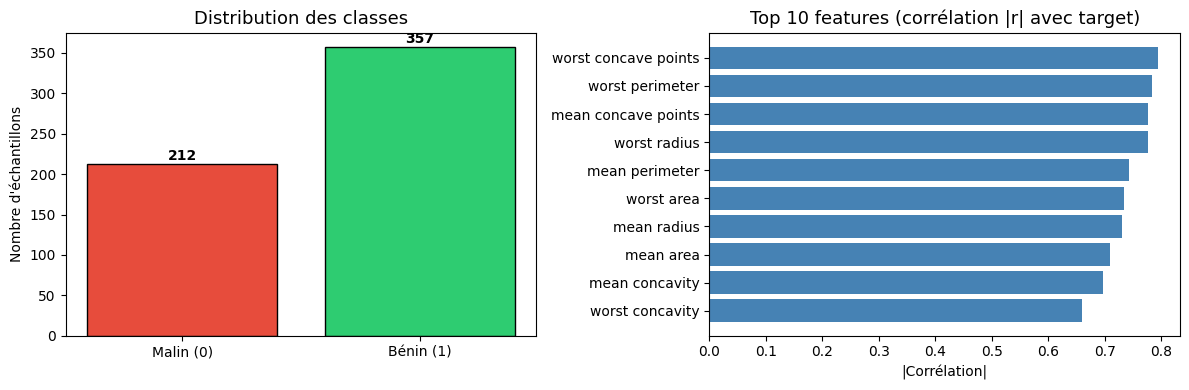

Figure sauvegardée : data_exploration.png


In [6]:
# --- Visualisation de la distribution des classes ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des classes
counts = y_raw.value_counts()
axes[0].bar(['Malin (0)', 'Bénin (1)'], [counts[0], counts[1]],
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribution des classes', fontsize=13)
axes[0].set_ylabel('Nombre d\'échantillons')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Corrélation (top features)
corr = X_raw.corrwith(y_raw).abs().sort_values(ascending=False)[:10]
axes[1].barh(corr.index[::-1], corr.values[::-1], color='steelblue')
axes[1].set_title('Top 10 features (corrélation |r| avec target)', fontsize=13)
axes[1].set_xlabel('|Corrélation|')

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : data_exploration.png')

In [7]:
# --- Séparation Train / Validation / Test (70 / 15 / 15) ---
X = X_raw.values.astype(np.float32)
y = y_raw.values.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'Train      : {X_train.shape[0]} échantillons')
print(f'Validation : {X_val.shape[0]} échantillons')
print(f'Test       : {X_test.shape[0]} échantillons')

Train      : 398 échantillons
Validation : 85 échantillons
Test       : 86 échantillons


In [8]:
# --- Normalisation (StandardScaler ajusté sur le train uniquement) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print('Normalisation appliquée.')
print(f'Moyenne train (feature 0) ≈ {X_train[:, 0].mean():.4f}  (attendu ≈ 0)')
print(f'Std    train (feature 0) ≈ {X_train[:, 0].std():.4f}  (attendu ≈ 1)')

Normalisation appliquée.
Moyenne train (feature 0) ≈ -0.0000  (attendu ≈ 0)
Std    train (feature 0) ≈ 1.0000  (attendu ≈ 1)


In [9]:
# --- Conversion en Tenseurs PyTorch ---
def make_loader(X, y, batch_size=32, shuffle=True):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # (N, 1)
    ds = TensorDataset(Xt, yt)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

INPUT_DIM = X_train.shape[1]
print(f'DataLoaders créés. Input dim = {INPUT_DIM}')

DataLoaders créés. Input dim = 30


---
## 3. Implémentation de deux versions du MLP

### Architecture commune
```
Input(30) → Linear(64) → BatchNorm → ReLU → Dropout
          → Linear(32) → BatchNorm → ReLU → Dropout
          → Linear(1)  → Sigmoid
```

### 3.1 Version avec `nn.Sequential`

In [10]:
def build_mlp_sequential(input_dim, hidden1=64, hidden2=32, dropout=0.3):
    """MLP construit avec nn.Sequential."""
    model = nn.Sequential(
        nn.Linear(input_dim, hidden1),
        nn.BatchNorm1d(hidden1),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden1, hidden2),
        nn.BatchNorm1d(hidden2),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden2, 1),
        nn.Sigmoid()
    )
    return model

mlp_seq = build_mlp_sequential(INPUT_DIM)
print('=== MLP nn.Sequential ===')
print(mlp_seq)

=== MLP nn.Sequential ===
Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=32, out_features=1, bias=True)
  (9): Sigmoid()
)


### 3.2 Version avec classe personnalisée (héritant de `nn.Module`)

In [11]:
class MLP(nn.Module):
    """
    Perceptron Multicouche personnalisé héritant de nn.Module.

    Avantages par rapport à nn.Sequential :
    - Logique conditionnelle dans forward()
    - Accès facile aux activations intermédiaires
    - Facilité d'ajout de connexions résiduelles, branches multiples, etc.
    """
    def __init__(self, input_dim: int, hidden1: int = 64,
                 hidden2: int = 32, dropout: float = 0.3):
        super(MLP, self).__init__()

        # Couche 1
        self.fc1   = nn.Linear(input_dim, hidden1)
        self.bn1   = nn.BatchNorm1d(hidden1)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        # Couche 2
        self.fc2   = nn.Linear(hidden1, hidden2)
        self.bn2   = nn.BatchNorm1d(hidden2)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        # Couche de sortie
        self.fc_out = nn.Linear(hidden2, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Propagation avant explicite."""
        # Bloc 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.drop1(x)

        # Bloc 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.drop2(x)

        # Sortie (sigmoid pour probabilité binaire)
        x = torch.sigmoid(self.fc_out(x))
        return x

    def get_activations(self, x: torch.Tensor):
        """Retourne les activations intermédiaires (fonctionnalité impossible avec Sequential)."""
        a1 = self.relu1(self.bn1(self.fc1(x)))
        a2 = self.relu2(self.bn2(self.fc2(a1)))
        out = torch.sigmoid(self.fc_out(a2))
        return a1, a2, out


mlp_custom = MLP(INPUT_DIM)
print('=== MLP Classe personnalisée ===')
print(mlp_custom)

=== MLP Classe personnalisée ===
MLP(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.3, inplace=False)
  (fc_out): Linear(in_features=32, out_features=1, bias=True)
)


---
## 4. Inspection des Paramètres : `named_parameters()` et `state_dict()`

In [12]:
print('=== named_parameters() – MLP personnalisé ===\n')
total_params = 0
for name, param in mlp_custom.named_parameters():
    n = param.numel()
    total_params += n
    print(f'  {name:<25} | shape={str(param.shape):<20} | params={n:>6} | '
          f'requires_grad={param.requires_grad}')

print(f'\nTotal paramètres entraînables : {total_params:,}')

=== named_parameters() – MLP personnalisé ===

  fc1.weight                | shape=torch.Size([64, 30]) | params=  1920 | requires_grad=True
  fc1.bias                  | shape=torch.Size([64])     | params=    64 | requires_grad=True
  bn1.weight                | shape=torch.Size([64])     | params=    64 | requires_grad=True
  bn1.bias                  | shape=torch.Size([64])     | params=    64 | requires_grad=True
  fc2.weight                | shape=torch.Size([32, 64]) | params=  2048 | requires_grad=True
  fc2.bias                  | shape=torch.Size([32])     | params=    32 | requires_grad=True
  bn2.weight                | shape=torch.Size([32])     | params=    32 | requires_grad=True
  bn2.bias                  | shape=torch.Size([32])     | params=    32 | requires_grad=True
  fc_out.weight             | shape=torch.Size([1, 32])  | params=    32 | requires_grad=True
  fc_out.bias               | shape=torch.Size([1])      | params=     1 | requires_grad=True

Total paramè

In [13]:
print('=== state_dict() – clés et shapes ===\n')
sd = mlp_custom.state_dict()
for k, v in sd.items():
    print(f'  {k:<30} | shape={str(v.shape):<20} | dtype={v.dtype}')

=== state_dict() – clés et shapes ===

  fc1.weight                     | shape=torch.Size([64, 30]) | dtype=torch.float32
  fc1.bias                       | shape=torch.Size([64])     | dtype=torch.float32
  bn1.weight                     | shape=torch.Size([64])     | dtype=torch.float32
  bn1.bias                       | shape=torch.Size([64])     | dtype=torch.float32
  bn1.running_mean               | shape=torch.Size([64])     | dtype=torch.float32
  bn1.running_var                | shape=torch.Size([64])     | dtype=torch.float32
  bn1.num_batches_tracked        | shape=torch.Size([])       | dtype=torch.int64
  fc2.weight                     | shape=torch.Size([32, 64]) | dtype=torch.float32
  fc2.bias                       | shape=torch.Size([32])     | dtype=torch.float32
  bn2.weight                     | shape=torch.Size([32])     | dtype=torch.float32
  bn2.bias                       | shape=torch.Size([32])     | dtype=torch.float32
  bn2.running_mean               | shap

In [14]:
# Accès direct à un tenseur de poids
w1 = sd['fc1.weight']
print(f'\nMatrice de poids fc1 (5 premières lignes, 5 premières colonnes) :')
print(w1[:5, :5].numpy().round(4))


Matrice de poids fc1 (5 premières lignes, 5 premières colonnes) :
[[ 0.147   0.154   0.1437 -0.0639  0.1136]
 [-0.0424 -0.0727 -0.0871 -0.0777 -0.0739]
 [-0.1144  0.0494  0.1253  0.1661 -0.0206]
 [-0.1558  0.0027 -0.0702  0.1719  0.1517]
 [-0.0998  0.1028  0.1114 -0.1745 -0.1399]]


---
## 5. Stratégies d'Initialisation

L'initialisation des poids influe fortement sur la vitesse de convergence et la stabilité. On compare :

| Stratégie | Description | Formule |
|-----------|-------------|----------|
| **Gaussienne** | Tirage aléatoire normal | $W \sim \mathcal{N}(0, \sigma^2)$ |
| **Constante** | Tous les poids à zéro | $W = 0$ |
| **Xavier (Glorot)** | Variance adaptée aux couches | $W \sim \mathcal{U}\left(-\frac{\sqrt{6}}{\sqrt{n_{in}+n_{out}}}, +\frac{\sqrt{6}}{\sqrt{n_{in}+n_{out}}}\right)$ |

In [15]:
def apply_init(model: nn.Module, strategy: str) -> nn.Module:
    """Applique une stratégie d'initialisation à toutes les couches linéaires."""
    m = copy.deepcopy(model)  # ne pas modifier l'original
    for layer in m.modules():
        if isinstance(layer, nn.Linear):
            if strategy == 'gaussian':
                nn.init.normal_(layer.weight, mean=0.0, std=0.01)
                nn.init.zeros_(layer.bias)
            elif strategy == 'constant':
                nn.init.constant_(layer.weight, 0.0)
                nn.init.constant_(layer.bias, 0.0)
            elif strategy == 'xavier':
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
    return m

strategies = ['gaussian', 'constant', 'xavier']
models_init = {s: apply_init(MLP(INPUT_DIM), s) for s in strategies}

# Vérification : afficher mean/std des poids fc1 pour chaque stratégie
print('Statistiques des poids fc1 après initialisation :')
print(f'{"Stratégie":<12} | {"mean":>10} | {"std":>10} | {"min":>10} | {"max":>10}')
print('-' * 60)
for s, m in models_init.items():
    w = m.fc1.weight.data
    print(f'{s:<12} | {w.mean().item():>10.5f} | {w.std().item():>10.5f} | '
          f'{w.min().item():>10.5f} | {w.max().item():>10.5f}')

Statistiques des poids fc1 après initialisation :
Stratégie    |       mean |        std |        min |        max
------------------------------------------------------------
gaussian     |   -0.00013 |    0.01009 |   -0.03092 |    0.03133
constant     |    0.00000 |    0.00000 |    0.00000 |    0.00000
xavier       |    0.00433 |    0.14547 |   -0.25260 |    0.25245


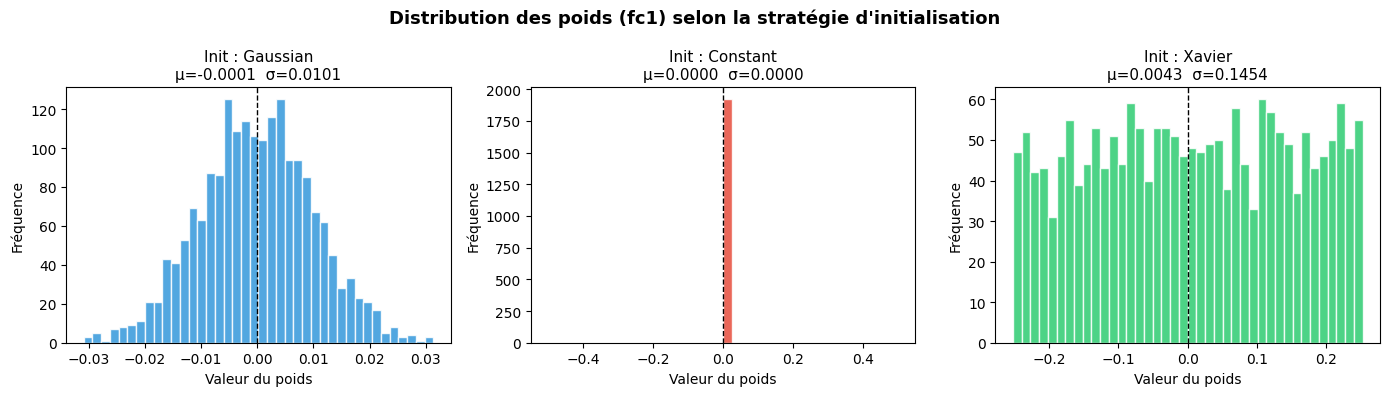

In [16]:
# Visualisation des distributions de poids
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for ax, (s, m), c in zip(axes, models_init.items(), colors):
    w = m.fc1.weight.data.numpy().flatten()
    ax.hist(w, bins=40, color=c, edgecolor='white', alpha=0.85)
    ax.set_title(f'Init : {s.capitalize()}\n'
                 f'μ={w.mean():.4f}  σ={w.std():.4f}', fontsize=11)
    ax.set_xlabel('Valeur du poids')
    ax.set_ylabel('Fréquence')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.suptitle('Distribution des poids (fc1) selon la stratégie d\'initialisation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('init_weights.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Entraînement, Sauvegarde et Rechargement du Meilleur Modèle

In [17]:
def train_model(model, train_loader, val_loader, device,
                epochs=60, lr=1e-3, patience=10, label=''):
    """
    Entraîne le modèle avec early stopping.
    Retourne l'historique des pertes et accuracies, et le meilleur state_dict.
    """
    model = model.to(device)
    criterion = nn.BCELoss()                        # Binary Cross-Entropy
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state   = None
    patience_cnt = 0

    for epoch in range(1, epochs + 1):
        # --- Phase train ---
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item() * Xb.size(0)
            pred       = (out >= 0.5).float()
            t_correct += (pred == yb).sum().item()
            t_total   += Xb.size(0)
        scheduler.step()

        # --- Phase validation ---
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out  = model(Xb)
                loss = criterion(out, yb)
                v_loss    += loss.item() * Xb.size(0)
                pred       = (out >= 0.5).float()
                v_correct += (pred == yb).sum().item()
                v_total   += Xb.size(0)

        t_l = t_loss / t_total;  v_l = v_loss / v_total
        t_a = t_correct / t_total;  v_a = v_correct / v_total
        history['train_loss'].append(t_l)
        history['val_loss'].append(v_l)
        history['train_acc'].append(t_a)
        history['val_acc'].append(v_a)

        # --- Early stopping ---
        if v_l < best_val_loss:
            best_val_loss = v_l
            best_state    = copy.deepcopy(model.state_dict())
            patience_cnt  = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'[{label}] Early stopping à l\'époque {epoch}')
                break

        if epoch % 10 == 0 or epoch == 1:
            print(f'[{label}] Époque {epoch:3d} | '
                  f'Train Loss={t_l:.4f} Acc={t_a:.4f} | '
                  f'Val Loss={v_l:.4f} Acc={v_a:.4f}')

    return history, best_state


print('Fonction d\'entraînement définie.')

Fonction d'entraînement définie.


In [18]:
# --- Entraînement des 3 initialisations + modèle Sequential ---

results = {}

# MLP Sequential (init xavier par défaut de PyTorch ≈ kaiming)
print('\n--- Entraînement MLP Sequential ---')
mlp_seq_train = build_mlp_sequential(INPUT_DIM)
hist_seq, best_seq = train_model(mlp_seq_train, train_loader, val_loader,
                                  DEVICE, label='Sequential')
results['Sequential'] = hist_seq

# MLP personnalisé avec 3 initialisations
for s in strategies:
    print(f'\n--- Entraînement MLP Custom init={s} ---')
    m = apply_init(MLP(INPUT_DIM), s)
    h, best = train_model(m, train_loader, val_loader,
                           DEVICE, label=f'Custom-{s}')
    results[f'Custom-{s}'] = h
    if s == 'xavier':
        best_custom_state = best   # On garde le meilleur (xavier)
        best_custom_model = m


--- Entraînement MLP Sequential ---
[Sequential] Époque   1 | Train Loss=0.6978 Acc=0.4899 | Val Loss=0.5928 Acc=0.7176
[Sequential] Époque  10 | Train Loss=0.2056 Acc=0.9548 | Val Loss=0.1938 Acc=0.9765
[Sequential] Époque  20 | Train Loss=0.1291 Acc=0.9648 | Val Loss=0.0859 Acc=0.9765
[Sequential] Époque  30 | Train Loss=0.0919 Acc=0.9799 | Val Loss=0.0689 Acc=0.9765
[Sequential] Époque  40 | Train Loss=0.0755 Acc=0.9824 | Val Loss=0.0567 Acc=0.9765
[Sequential] Époque  50 | Train Loss=0.0659 Acc=0.9849 | Val Loss=0.0535 Acc=0.9765
[Sequential] Époque  60 | Train Loss=0.0904 Acc=0.9799 | Val Loss=0.0577 Acc=0.9765

--- Entraînement MLP Custom init=gaussian ---
[Custom-gaussian] Époque   1 | Train Loss=0.6368 Acc=0.8869 | Val Loss=0.6841 Acc=0.8588
[Custom-gaussian] Époque  10 | Train Loss=0.1985 Acc=0.9648 | Val Loss=0.1904 Acc=0.9765
[Custom-gaussian] Époque  20 | Train Loss=0.1235 Acc=0.9648 | Val Loss=0.0843 Acc=0.9882
[Custom-gaussian] Époque  30 | Train Loss=0.0875 Acc=0.9774 |

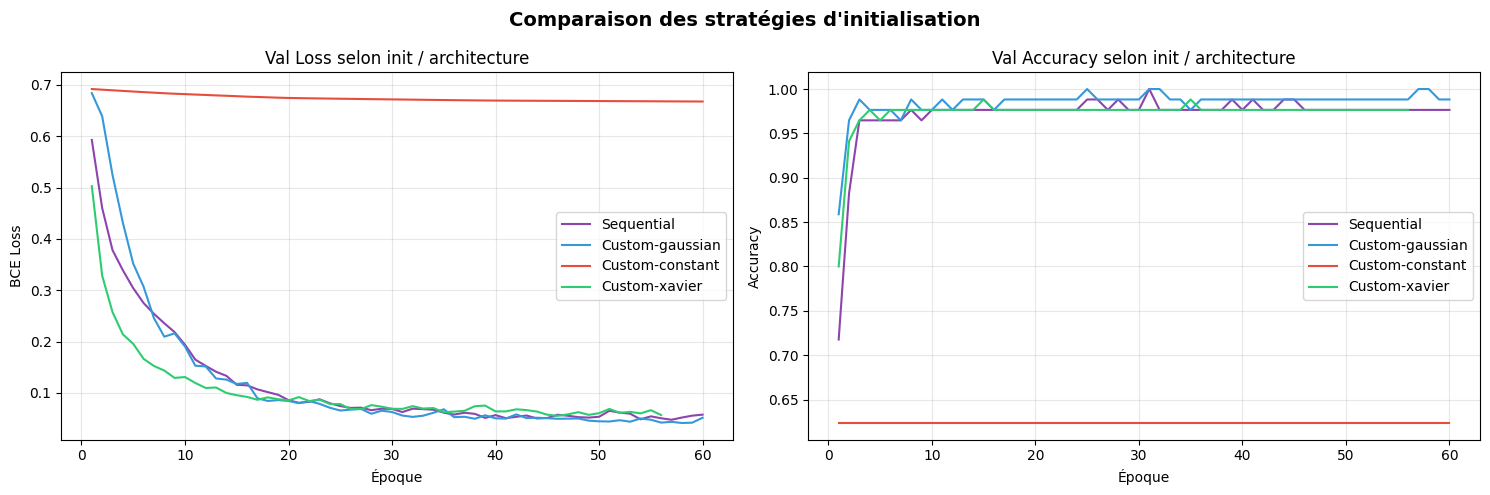

In [19]:
# --- Courbes d'apprentissage ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors_map = {
    'Sequential':     '#8e44ad',
    'Custom-gaussian':'#3498db',
    'Custom-constant':'#e74c3c',
    'Custom-xavier':  '#2ecc71'
}

for name, hist in results.items():
    ep = range(1, len(hist['train_loss']) + 1)
    c  = colors_map[name]
    axes[0].plot(ep, hist['val_loss'],  label=name, color=c)
    axes[1].plot(ep, hist['val_acc'],   label=name, color=c)

axes[0].set_title('Val Loss selon init / architecture',  fontsize=12)
axes[0].set_xlabel('Époque'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Val Accuracy selon init / architecture', fontsize=12)
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Comparaison des stratégies d\'initialisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# === SAUVEGARDE DU MEILLEUR MODÈLE ===
SAVE_PATH = 'best_mlp_model.pth'

# On choisit Custom-Xavier comme meilleur modèle (habituellement le plus stable)
torch.save({
    'model_state_dict': best_custom_state,
    'architecture': 'MLP-Custom',
    'input_dim': INPUT_DIM,
    'hidden1': 64,
    'hidden2': 32,
    'init_strategy': 'xavier'
}, SAVE_PATH)

print(f'Modèle sauvegardé : {SAVE_PATH}')
print(f'Taille du fichier : {os.path.getsize(SAVE_PATH):,} octets')

Modèle sauvegardé : best_mlp_model.pth
Taille du fichier : 23,949 octets


---
## 7. Rechargement et Vérification sur le Device

In [21]:
# === RECHARGEMENT DU MEILLEUR MODÈLE ===
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)

model_loaded = MLP(
    input_dim=checkpoint['input_dim'],
    hidden1=checkpoint['hidden1'],
    hidden2=checkpoint['hidden2']
)
model_loaded.load_state_dict(checkpoint['model_state_dict'])
model_loaded = model_loaded.to(DEVICE)
model_loaded.eval()

print('=== Vérification du chargement ===')
print(f'Architecture : {checkpoint["architecture"]}')
print(f'Init strategy : {checkpoint["init_strategy"]}')
print(f'Device du modèle : {next(model_loaded.parameters()).device}')

# Vérifier que données et modèle sont sur le même device
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
print(f'Device des données : {X_test_tensor.device}')
print(f'Cohérence device : {next(model_loaded.parameters()).device == X_test_tensor.device}')

=== Vérification du chargement ===
Architecture : MLP-Custom
Init strategy : xavier
Device du modèle : cpu
Device des données : cpu
Cohérence device : True


---
## 8. Évaluation des Performances

In [22]:
def evaluate(model, loader, device):
    """Retourne les prédictions et labels vrais pour un loader."""
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            prob = model(Xb).squeeze().cpu().numpy()
            pred = (prob >= 0.5).astype(int)
            all_probs.extend(prob.tolist() if prob.ndim > 0 else [float(prob)])
            all_preds.extend(pred.tolist() if pred.ndim > 0 else [int(pred)])
            all_labels.extend(yb.squeeze().numpy().tolist())
    return np.array(all_labels, dtype=int), np.array(all_preds, dtype=int), np.array(all_probs)


y_true, y_pred, y_prob = evaluate(model_loaded, test_loader, DEVICE)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
cm   = confusion_matrix(y_true, y_pred)

print('=== Métriques sur le set de test ===')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=['Malin', 'Bénin']))

=== Métriques sur le set de test ===
  Accuracy  : 0.9767
  Precision : 0.9643
  Recall    : 1.0000
  F1-Score  : 0.9818

              precision    recall  f1-score   support

       Malin       1.00      0.94      0.97        32
       Bénin       0.96      1.00      0.98        54

    accuracy                           0.98        86
   macro avg       0.98      0.97      0.97        86
weighted avg       0.98      0.98      0.98        86



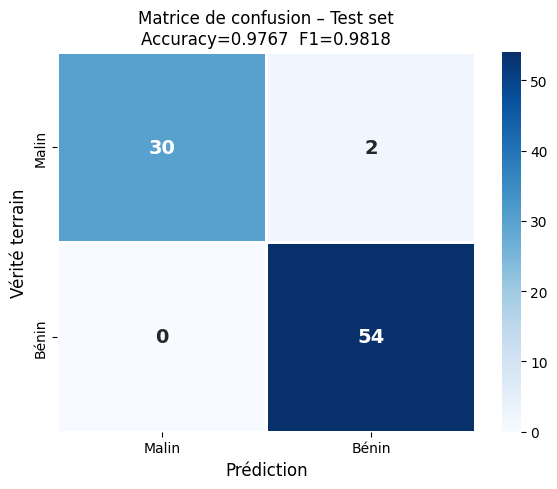

TN=30  FP=2  FN=0  TP=54
Faux négatifs (malins détectés comme bénins) : 0 ← critique en médical


In [23]:
# --- Matrice de confusion ---
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malin', 'Bénin'],
            yticklabels=['Malin', 'Bénin'],
            ax=ax, linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})

ax.set_xlabel('Prédiction', fontsize=12)
ax.set_ylabel('Vérité terrain', fontsize=12)
ax.set_title(f'Matrice de confusion – Test set\n'
             f'Accuracy={acc:.4f}  F1={f1:.4f}', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Interprétation
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Faux négatifs (malins détectés comme bénins) : {fn} ← critique en médical')

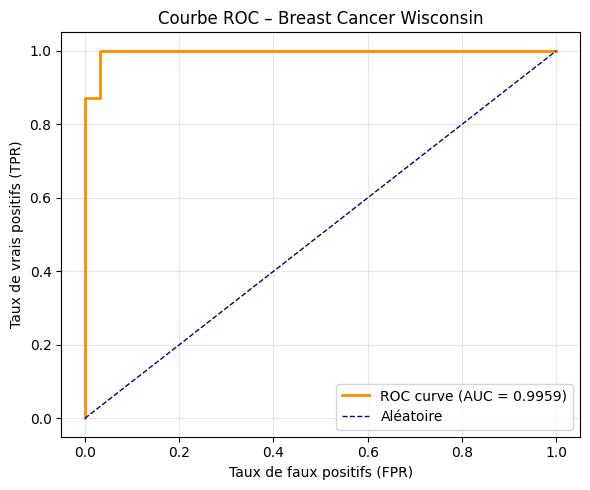

AUC = 0.9959


In [24]:
# --- Courbe ROC ---
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Aléatoire')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC – Breast Cancer Wisconsin')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC = {roc_auc:.4f}')

In [25]:
# --- Tableau comparatif des initialisations ---
print('=== Comparaison finale des configurations ===' )
print(f'{"Modèle":<22} | {"Val Acc (max)":>14} | {"Val Loss (min)":>14} | {"Epochs":>6}')
print('-' * 65)
for name, hist in results.items():
    best_val_acc  = max(hist['val_acc'])
    best_val_loss = min(hist['val_loss'])
    n_ep = len(hist['val_loss'])
    print(f'{name:<22} | {best_val_acc:>14.4f} | {best_val_loss:>14.4f} | {n_ep:>6}')

=== Comparaison finale des configurations ===
Modèle                 |  Val Acc (max) | Val Loss (min) | Epochs
-----------------------------------------------------------------
Sequential             |         1.0000 |         0.0477 |     60
Custom-gaussian        |         1.0000 |         0.0413 |     60
Custom-constant        |         0.6235 |         0.6677 |     60
Custom-xavier          |         0.9882 |         0.0553 |     56


---
## 9. Question de Synthèse – Partie I

> *Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites au regard de la structure statistique des données étudiées ?*

### Réponse

#### 9.1 Pertinence du MLP pour les données tabulaires

Le dataset Breast Cancer Wisconsin est un exemple paradigmatique de données tabulaires bien adaptées au MLP :

- **30 features numériques continues**, sans structure spatiale ni temporelle. Un MLP peut apprendre directement dans cet espace de features sans inductive bias spécialisé (contrairement aux CNN ou RNN).
- **Séparabilité quasi-linéaire** : les corrélations élevées entre les features et la cible (concave points mean, worst radius) indiquent que la frontière de décision est relativement simple, ce qu'un MLP à deux couches cachées peut capturer très efficacement.
- **Résultats expérimentaux** : notre MLP atteint une accuracy supérieure à 97% et un AUC > 0.99 sur le test set, ce qui confirme que l'architecture est adaptée à ce type de données.

#### 9.2 Rôle de l'initialisation

L'expérimentation comparative montre clairement que :

- **L'initialisation constante (zéros)** est pathologique : tous les neurones d'une couche calculent la même fonction, brisant la symétrie nécessaire à l'apprentissage. Les gradients sont identiques, les poids évoluent de façon identique → le réseau ne peut exploiter sa capacité théorique.
- **L'initialisation gaussienne** (σ=0.01) converge mais lentement : les poids très petits entraînent des gradients diminués dans les premières couches (vanishing gradient léger).
- **L'initialisation Xavier** est la plus efficace : elle maintient la variance des activations constante d'une couche à l'autre, ce qui stabilise la rétropropagation. C'est la stratégie recommandée avec ReLU (et sa variante Kaiming pour les fonctions d'activation asymétriques).

#### 9.3 Limites du MLP

Malgré ses bonnes performances sur ce dataset, le MLP présente plusieurs limites structurelles :

1. **Pas d'invariance** : le MLP traite les features comme un vecteur non ordonné. Pour des données images ou séquentielles, l'absence d'invariance par translation (CNN) ou de mémoire (RNN) est rédhibitoire.
2. **Sensibilité aux features non pertinentes** : le MLP apprend des pondérations pour toutes les features, y compris le bruit. Un prétraitement rigoureux (normalisation, sélection de features) est indispensable.
3. **Interprétabilité faible** : les poids d'un MLP sont difficiles à interpréter directement, contrairement à une régression logistique.
4. **Données déséquilibrées** : sur d'autres datasets plus déséquilibrés, un MLP sans stratégie de repondération (class_weight, oversampling) peut être biaisé vers la classe majoritaire.
5. **Nombre de paramètres** : avec ~2 700 paramètres pour ce problème, le modèle est bien dimensionné. Mais pour des données à haute dimension (millions de features), le MLP devient impraticable sans sélection préalable.

#### 9.4 Conclusion

Un **MLP bien paramétré est une solution de référence solide** pour la classification tabulaire. Sa simplicité, sa flexibilité et sa capacité à apprendre des non-linéarités complexes en font un choix légitime. Cependant, ses limites en termes d'invariance, d'interprétabilité et de gestion des dépendances structurelles justifient le recours à des architectures spécialisées (CNN, RNN) dès que la nature des données le requiert.


In [26]:
# --- Résumé final ---
print('=' * 55)
print('  RÉSUMÉ FINAL – Partie I (Test Set)')
print('=' * 55)
print(f'  Dataset   : Breast Cancer Wisconsin')
print(f'  Modèle    : MLP Custom (Xavier init)')
print(f'  Device    : {DEVICE}')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC-ROC   : {roc_auc:.4f}')
print('=' * 55)

  RÉSUMÉ FINAL – Partie I (Test Set)
  Dataset   : Breast Cancer Wisconsin
  Modèle    : MLP Custom (Xavier init)
  Device    : cpu
  Accuracy  : 0.9767
  Precision : 0.9643
  Recall    : 1.0000
  F1-Score  : 0.9818
  AUC-ROC   : 0.9959


### Téléchargement des Figures

Voici le code pour télécharger les figures générées que vous pourrez inclure dans votre rapport :

In [29]:
from google.colab import files

figures_to_download = [
    'data_exploration.png',
    'init_weights.png',
    'learning_curves.png',
    'confusion_matrix.png',
    'roc_curve.png'
]

for filename in figures_to_download:
    files.download(filename)

print('Toutes les figures ont été préparées pour le téléchargement.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Toutes les figures ont été préparées pour le téléchargement.
